In [19]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.color import rgb2gray
from skimage import restoration
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [54]:
blur_folder = "../data/blur"
sharp_folder = "../data/sharp"

images = [img for img in os.listdir(blur_folder) if img.endswith('.png')]
print(images)

['000131.png', '000132.png', '000133.png', '000134.png', '000135.png']


In [52]:
# blur kernel
psf = np.ones((5,5))/25
psf

array([[0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04],
       [0.04, 0.04, 0.04, 0.04, 0.04]])

In [89]:
# store result for each image
psnr_wiener_list = []
ssim_wiener_list = []

psnr_rl_list = []
ssim_rl_list = []

processed_images = []

PSNR wiener : 28.066 , PSNR RL : 24.218
SSIM wiener : 0.870, SSIM rl 0.847


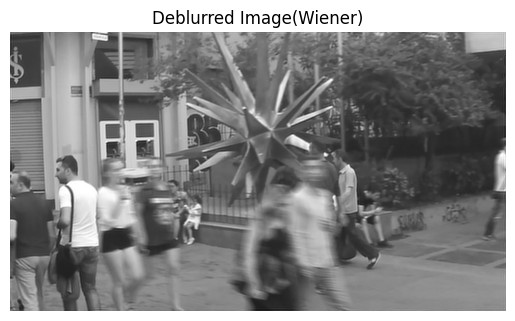

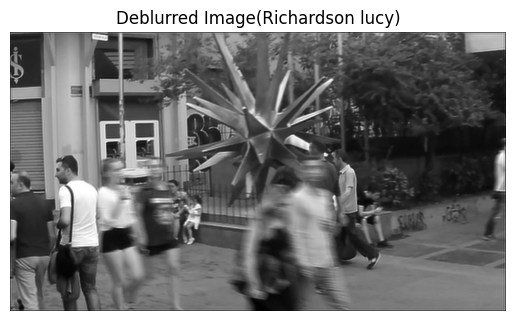

PSNR wiener : 27.998 , PSNR RL : 24.189
SSIM wiener : 0.869, SSIM rl 0.843


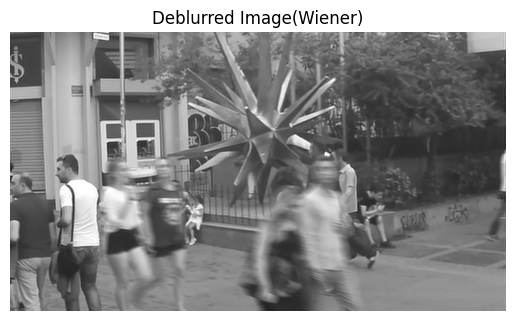

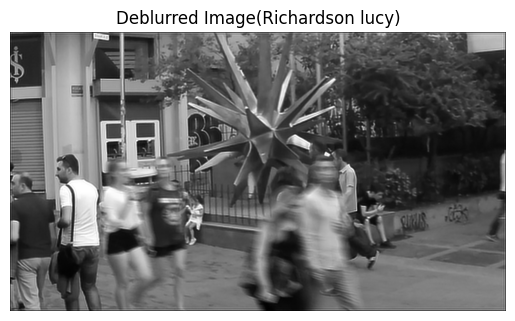

PSNR wiener : 28.034 , PSNR RL : 24.278
SSIM wiener : 0.869, SSIM rl 0.843


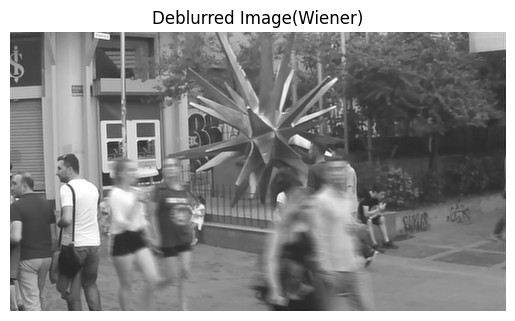

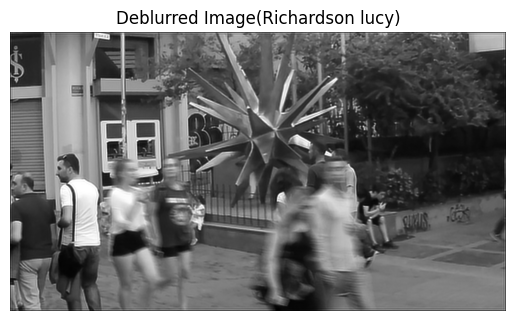

PSNR wiener : 27.018 , PSNR RL : 23.904
SSIM wiener : 0.853, SSIM rl 0.829


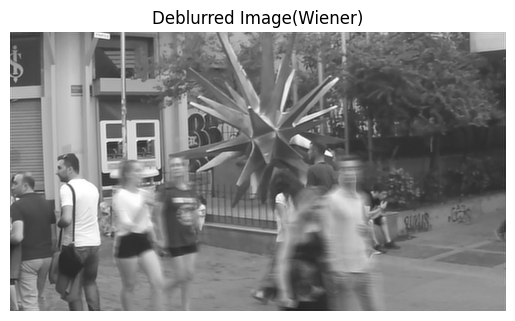

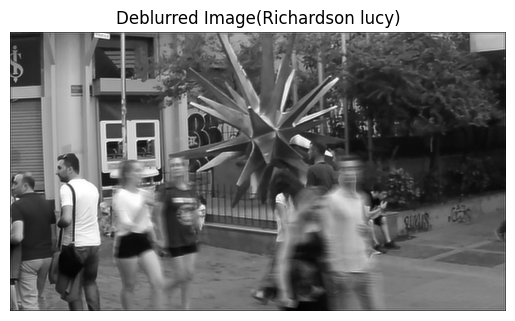

PSNR wiener : 28.238 , PSNR RL : 24.424
SSIM wiener : 0.873, SSIM rl 0.847


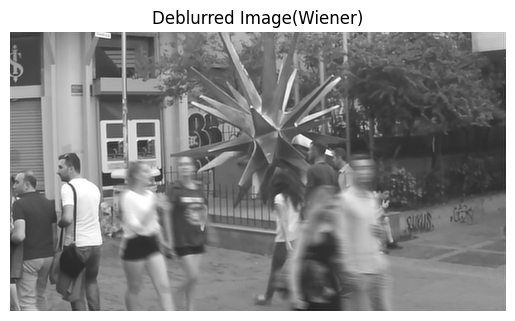

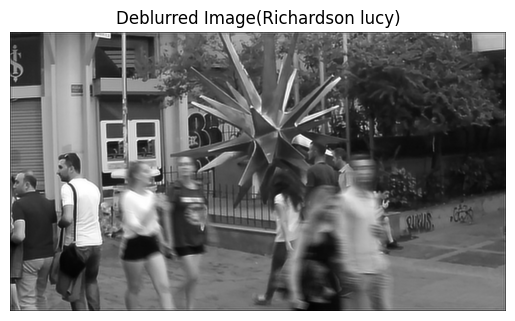

In [90]:
for img in images:
    
    blur_path = os.path.join(blur_folder, img)
    sharp_path = os.path.join(sharp_folder, img)

    blur_img = cv2.imread(blur_path, 0)   # grayscale
    sharp_img = cv2.imread(sharp_path, 0)

    # safety check
    if blur_img is None or sharp_img is None:
        print("Error loading:", img)
        continue

    # normalize
    blur_img = blur_img / 255.0
    sharp_img = sharp_img / 255.0

    # Wiener
    wiener_img = restoration.wiener(blur_img, psf, balance=0.1)

    # richardson-lucy
    rl_img = restoration.richardson_lucy(blur_img, psf, num_iter=10)

    # Metrics values
    psnr_wiener = psnr(sharp_img, wiener_img)
    psnr_rl = psnr(sharp_img, rl_img)
    print(f"PSNR wiener : {psnr_wiener:.3f} , PSNR RL : {psnr_rl :.3f}")

    # appending to lists
    psnr_wiener_list.append(psnr_wiener)
    psnr_rl_list.append(psnr_rl)

    ssim_wiener = ssim(sharp_img, wiener_img, data_range=1.0)
    ssim_rl = ssim(sharp_img, rl_img, data_range=1.0)
    print(f"SSIM wiener : {ssim_wiener:.3f}, SSIM rl {ssim_rl:.3f}")

    # appending to lists
    ssim_wiener_list.append(ssim_wiener)
    ssim_rl_list.append(ssim_rl)

    # appending img to processed images 
    processed_images.append(img)
    
    
    plt.imshow(wiener_img, cmap='gray')
    plt.title("Deblurred Image(Wiener)")
    plt.axis("off")
    plt.show()

    plt.imshow(rl_img, cmap="gray")
    plt.title("Deblurred Image(Richardson lucy)")
    plt.axis("off")
    plt.show()

In [83]:
# # checking psnr values
# psnr_wiener = psnr(sharp_img, wiener_img)
# psnr_rl = psnr(sharp_img, rl_img)

# print(f"PSNR for Wiener Method : {psnr_wiener:.3f}")
# print(f"PSNR for Richardson_lucy Method : {psnr_rl:.3f}")

In [84]:
# # checking ssim values
#     ssim_wiener = ssim(sharp_img, wiener_img, data_range=1.0)
#     ssim_rl = ssim(sharp_img, rl_img, data_range=1.0)

# print(f"SSIM for Wiener {ssim_wiener:.3f}")
# print(f"SSIm for Richardson_lucy {ssim_rl:.3f}")

In [91]:
import pandas as pd

df = pd.DataFrame({
    "Image" : processed_images,
    "PSNR-Wiener": psnr_wiener_list,
    "PSNR-RL" : psnr_rl_list,
    "SSIM-Wiener" : ssim_wiener_list,
    "SSIM-RL" : ssim_rl_list
})

print(df)

        Image  PSNR-Wiener    PSNR-RL  SSIM-Wiener   SSIM-RL
0  000131.png    28.065884  24.218034     0.870289  0.846885
1  000132.png    27.997529  24.188895     0.868939  0.843373
2  000133.png    28.033906  24.277998     0.869385  0.842927
3  000134.png    27.018499  23.903765     0.853049  0.828977
4  000135.png    28.238438  24.423913     0.872676  0.847231


In [ ]:
# Qualitative Visual Comparisons

# Wiener methods helps improving the picture by deblurring it but it still keeps the noise.
# On the other hand, richardson_lucy method produces more sharper edges and introduced more detailed to picture as compared to wiener method. 
# But, the original image remains clear.